In [1]:
import os, sys
import numpy as np
import pandas as pd
from pathlib import Path
from time import process_time

from prod_fs import ProD

import matplotlib.pyplot as plt
from matplotlib import rc
plt.rcParams['font.serif'] = ['CMU Serif']
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
plt.rcParams['font.size'] = 11

# According to Canedo (2012), 3 % of 561 features = 17 features
nRetainedFeatures = 17

# Plot the top feature
selTopFeature = 0

Xtrain = pd.read_csv(
    Path("data") / "train" / "X_train.txt", sep=r'\s+', header=None
).values
ytrain = pd.read_csv(
    Path("data") / "train" / "y_train.txt", sep=r'\s+',
    header=None, index_col=None
)
ytrain = np.reshape(ytrain, -1)
ytrain

array([5, 5, 5, ..., 2, 2, 2])

In [2]:
mapping = {1: 'WALK', 2: 'WALK UP', 3: 'WALK DOWN', 4: 'SIT', 5: 'STAND', 6: 'LAY'}
ytrain = np.array([mapping[y] for y in ytrain])
ytrain

array(['STAND', 'STAND', 'STAND', ..., 'WALK UP', 'WALK UP', 'WALK UP'],
      dtype='<U9')

Constructing and evaluating the KDEs per class for every feature ... 
 - Kernels constructed!
Computing intersection areas ...
 - averaging_method: 'mean'
Averaging scheme: mean
Computing pairwise intersection areas ...


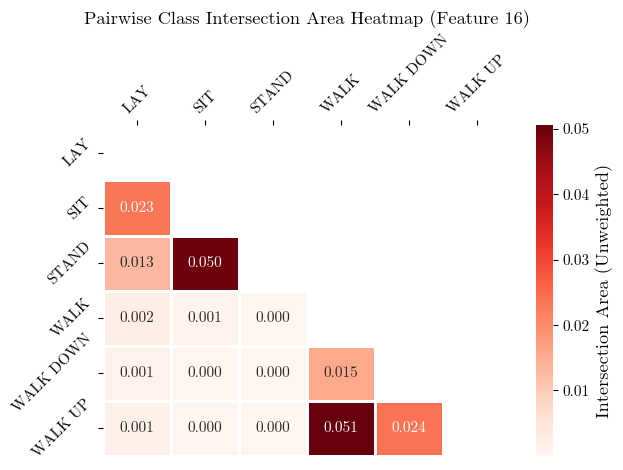

In [3]:
prodRanker = ProD(
    integration_method="trapz", delta=500, bw_method="scott",
    k=2, n_jobs=-1, mode="release", lower_end=-1.5, upper_end=2.5,
    averaging_method="mean"
)
prodRanker.fit(Xtrain, ytrain)

topFeatures = prodRanker.get_topnFeatures(nRetainedFeatures)

fig, ax = plt.subplots(1, 1)
prodRanker.plot_classPairHeatmaps(topFeatures[selTopFeature], _ax=ax)
fig.savefig("HARMean_HeatMap.pdf", format="pdf")
plt.show()

Constructing and evaluating the KDEs per class for every feature ... 
 - Kernels constructed!
Computing intersection areas ...
 - averaging_method: 'weighted'
Averaging scheme: weighted
Computing pairwise intersection areas ...
 - averaging_method: 'weighted'


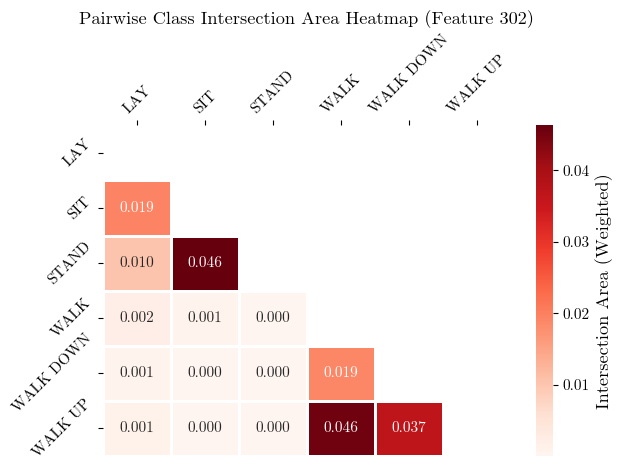

In [4]:
prodRankerWeighted = ProD(
    integration_method="trapz", delta=500, bw_method="scott",
    k=2, n_jobs=-1, mode="release", lower_end=-1.5, upper_end=2.5,
    averaging_method="weighted"
)
prodRankerWeighted.fit(Xtrain, ytrain)

topFeaturesWeighted = prodRankerWeighted.get_topnFeatures(nRetainedFeatures)

fig, ax = plt.subplots(1, 1)
prodRankerWeighted.plot_classPairHeatmaps(topFeaturesWeighted[selTopFeature], _ax=ax)
fig.savefig("HARWeighted_HeatMap.pdf", format="pdf")
plt.show()